In [1]:
import matplotlib.pyplot as plt
import audioflux as af
import numpy as np
from audioflux.type import SpectralFilterBankScaleType, SpectralDataType
from audioflux.display import fill_spec
from audioflux.display import fill_plot, fill_wave

In [2]:
import os
import pandas as pd

In [8]:
import numpy as np
import pandas as pd

from pathlib import Path
import pandas as pd
import numpy as np

stats_dir = Path('women_thresh_detect')

dfs = []
for f in sorted(stats_dir.glob('*.stats.csv')):
    vid_id = f.name.split('.')[0]
    df = pd.read_csv(f)
    df['video_id'] = vid_id
    dfs.append(df)

rgb_df = pd.concat(dfs, ignore_index=True)

summary = (
    rgb_df.groupby('video_id')['average_rgb']
    .agg(brightness_mean='mean', brightness_std='std', brightness_range=lambda x: x.max() - x.min())
    .reset_index()
)

In [13]:
summary['video_id'] = summary['video_id'].astype(int).astype(str)

In [15]:
summary

,video_id,brightness_mean,brightness_std,brightness_range
0,1,95.523060,28.974293,230.779677
1,2,105.422041,29.653259,224.717385
2,3,180.604685,24.011966,181.231536
3,6,104.987225,46.617745,216.496185
4,7,66.775793,21.849713,124.726708
...,...,...,...,...
1365,1698,120.635193,33.084703,252.150620
1366,1699,57.586100,12.935008,70.795695
1367,1700,142.944151,25.834065,177.030979
1368,1701,71.720511,41.941039,240.563956


In [11]:
om = pd.read_csv("ad_info_filled.csv")
bo = pd.read_csv("info2.csv")

In [18]:
summary['video_id'] = summary['video_id'].astype(int)
bo['video_id'] = bo['video_id'].astype(int)

In [19]:
om = om.merge(summary, left_on='clip_id', right_on='video_id', how='left').drop(columns='video_id')
om = om.merge(bo[['video_id','mean_spectral_entropy','energy','rms','zcr']], left_on='clip_id', right_on='video_id', how='left').drop(columns='video_id')

In [21]:
om.to_csv("ad_change_stats.csv")

In [7]:
bruh = pd.read_csv("info_fixed_id.csv")
bruh['video_id'] = bruh['clip_id'].apply(lambda n: str(n).zfill(5))
bruh.to_csv("cand_info.csv")

In [6]:


with open('valid.txt', 'w') as f:
    for line in [x for x in bruh['video_id']]:
        f.write(f"{line}\n")


In [47]:
info2 = info2.merge(bruh, on = 'clip_id')
info2

,Unnamed: 0.1_x,Unnamed: 0_x,clip_id,title_x,duration_x,description_x,rep_x,ad_title_x,date_x,Unnamed: 9,...,Unnamed: 0_y,title_y,duration_y,description_y,rep_y,ad_title_y,date_y,dt,year_y,rep_year
0,462,628,631,Abby Finkenauer - Right Here,30,"Originally published on Oct. 27, 2020.",abbyfinkenauer,Right Here,"Oct. 27, 2020.",NaN,...,628,Abby Finkenauer - Right Here,30,"Originally published on Oct. 27, 2020.",Abby Finkenauer,Right Here,"Oct. 27, 2020.",2020-10-27,2020,"Abby Finkenauer, 2020"
1,463,629,632,Abby Finkenauer - Kyle,30,"Originally published on Oct. 20, 2020.",abbyfinkenauer,Kyle,"Oct. 20, 2020.",NaN,...,629,Abby Finkenauer - Kyle,30,"Originally published on Oct. 20, 2020.",Abby Finkenauer,Kyle,"Oct. 20, 2020.",2020-10-20,2020,"Abby Finkenauer, 2020"
2,464,630,633,Abby Finkenauer - Chair,30,"Originally published on Oct. 20, 2020.",abbyfinkenauer,Chair,"Oct. 20, 2020.",NaN,...,630,Abby Finkenauer - Chair,30,"Originally published on Oct. 20, 2020.",Abby Finkenauer,Chair,"Oct. 20, 2020.",2020-10-20,2020,"Abby Finkenauer, 2020"
3,465,631,634,Abby Finkenauer - Together,30,"Originally published on Oct. 8, 2020.",abbyfinkenauer,Together,"Oct. 8, 2020.",NaN,...,631,Abby Finkenauer - Together,30,"Originally published on Oct. 8, 2020.",Abby Finkenauer,Together,"Oct. 8, 2020.",2020-10-08,2020,"Abby Finkenauer, 2020"
4,466,632,635,Abby Finkenauer - Effective,30,"Originally published on Oct. 5, 2020.",abbyfinkenauer,Effective,"Oct. 5, 2020.",NaN,...,632,Abby Finkenauer - Effective,30,"Originally published on Oct. 5, 2020.",Abby Finkenauer,Effective,"Oct. 5, 2020.",2020-10-05,2020,"Abby Finkenauer, 2020"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1365,49,75,76,Yvette Herrell - Serve,30,"Originally published on Oct. 21, 2020.",yvetteherrell,Serve,"Oct. 21, 2020.",NaN,...,75,Yvette Herrell - Serve,30,"Originally published on Oct. 21, 2020.",Yvette Herrell,Serve,"Oct. 21, 2020.",2020-10-21,2020,"Yvette Herrell, 2020"
1366,50,76,77,Yvette Herrell - Yvette for Congress | Dog in ...,30,"Originally published on Aug. 18, 2022.",yvetteherrell,Yvette for Congress | Dog in the Fight,"Aug. 18, 2022.",NaN,...,76,Yvette Herrell - Yvette for Congress | Dog in ...,30,"Originally published on Aug. 18, 2022.",Yvette Herrell,Yvette for Congress | Dog in the Fight,"Aug. 18, 2022.",2022-08-18,2022,"Yvette Herrell, 2022"
1367,867,1064,1067,Yvette Herrell - Liberal,30,"Originally published on May 31, 2018",yvetteherrell,Liberal,"May 31, 2018",NaN,...,1064,Yvette Herrell - Liberal,30,"Originally published on May 31, 2018",Yvette Herrell,Liberal,"May 31, 2018",2018-05-31,2018,"Yvette Herrell, 2018"
1368,868,1065,1068,Yvette Herrell - Proven,30,"Originally published on May 21, 2018",yvetteherrell,Proven,"May 21, 2018",NaN,...,1065,Yvette Herrell - Proven,30,"Originally published on May 21, 2018",Yvette Herrell,Proven,"May 21, 2018",2018-05-21,2018,"Yvette Herrell, 2018"


/var/folders/87/9qwg67f164gck_jk0qq9fkc40000gn/T/ipykernel_94379/2209686635.py:1: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  plt.plot_date(info2['dt'], info2['energy'])


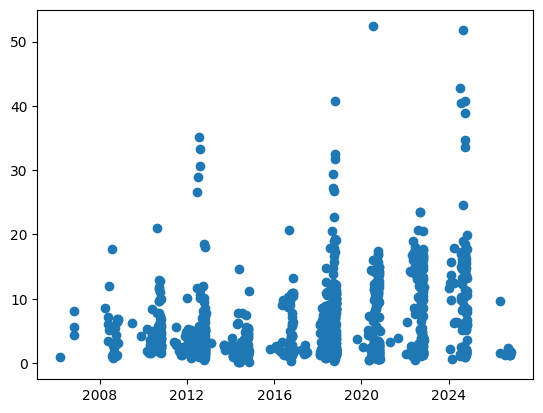

In [50]:
plt.plot_date(info2['dt'], info2['energy'])

/var/folders/87/9qwg67f164gck_jk0qq9fkc40000gn/T/ipykernel_94379/455321071.py:1: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  plt.plot_date(info2['dt'], info2['mean_spectral_entropy'])


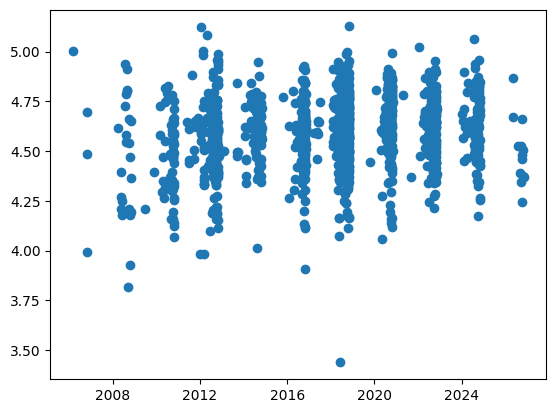

In [51]:
plt.plot_date(info2['dt'], info2['mean_spectral_entropy'])

/var/folders/87/9qwg67f164gck_jk0qq9fkc40000gn/T/ipykernel_94379/849939989.py:1: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  plt.plot_date(info2['dt'], info2['rms'])


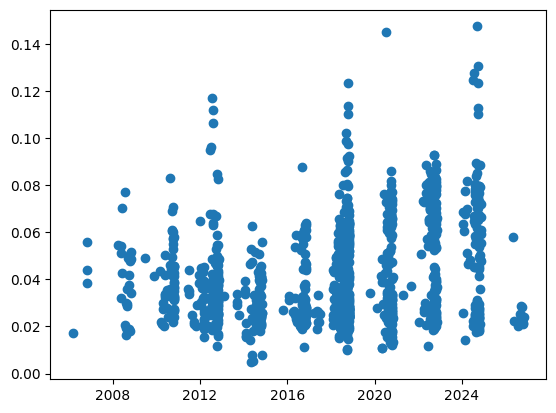

In [52]:
plt.plot_date(info2['dt'], info2['rms'])

/var/folders/87/9qwg67f164gck_jk0qq9fkc40000gn/T/ipykernel_94379/3478440732.py:1: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  plt.plot_date(info2['dt'], info2['zcr'])


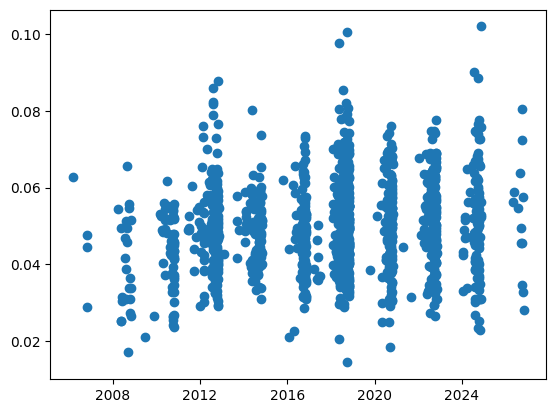

In [53]:
plt.plot_date(info2['dt'], info2['zcr'])

In [33]:
info = pd.read_excel("reps_vid_master.xlsx")
info

,Unnamed: 0.1,Unnamed: 0,clip_id,title,duration,description,rep,ad_title,date,Unnamed: 9,year
0,462,628,631,Abby Finkenauer - Right Here,30,"Originally published on Oct. 27, 2020.",abbyfinkenauer,Right Here,"Oct. 27, 2020.",NaN,2020
1,463,629,632,Abby Finkenauer - Kyle,30,"Originally published on Oct. 20, 2020.",abbyfinkenauer,Kyle,"Oct. 20, 2020.",NaN,2020
2,464,630,633,Abby Finkenauer - Chair,30,"Originally published on Oct. 20, 2020.",abbyfinkenauer,Chair,"Oct. 20, 2020.",NaN,2020
3,465,631,634,Abby Finkenauer - Together,30,"Originally published on Oct. 8, 2020.",abbyfinkenauer,Together,"Oct. 8, 2020.",NaN,2020
4,466,632,635,Abby Finkenauer - Effective,30,"Originally published on Oct. 5, 2020.",abbyfinkenauer,Effective,"Oct. 5, 2020.",NaN,2020
...,...,...,...,...,...,...,...,...,...,...,...
1365,49,75,76,Yvette Herrell - Serve,30,"Originally published on Oct. 21, 2020.",yvetteherrell,Serve,"Oct. 21, 2020.",NaN,2020
1366,50,76,77,Yvette Herrell - Yvette for Congress | Dog in ...,30,"Originally published on Aug. 18, 2022.",yvetteherrell,Yvette for Congress | Dog in the Fight,"Aug. 18, 2022.",NaN,2022
1367,867,1064,1067,Yvette Herrell - Liberal,30,"Originally published on May 31, 2018",yvetteherrell,Liberal,"May 31, 2018",NaN,2018
1368,868,1065,1068,Yvette Herrell - Proven,30,"Originally published on May 21, 2018",yvetteherrell,Proven,"May 21, 2018",NaN,2018


In [39]:
info['video_id'] = info['clip_id'].apply(lambda n: str(n).zfill(5))

In [38]:
info.to_csv("info_fixed_id.csv")

In [ ]:


wav_dir = "wav_output/"

def get_spec_avg (wav_path):
  audio_arr, sr  = af.read(wav_path)
  spec_arr, _ = af.mel_spectrogram(audio_arr, samplate = sr)
  bft_obj = af.BFT(num=128, radix2_exp=12, samplate=sr,
                 scale_type=SpectralFilterBankScaleType.MEL)
  spec_arr = bft_obj.bft(audio_arr)
  spec_arr = np.abs(spec_arr)
  audio_len = audio_arr.shape[-1]
  frame_probs = spec_arr / (spec_arr.sum(axis=0, keepdims=True) + 1e-10)
  entropy_per_frame = -np.sum(frame_probs * np.log2(frame_probs + 1e-10), axis=0)
  mean_spectral_entropy = entropy_per_frame.mean()
  return mean_spectral_entropy 

rows = []
for f in os.listdir(wav_dir):
    if f.endswith(".wav"):
        vid_id = f.replace(".wav", "")
        entropy = get_spec_avg(os.path.join(wav_dir, f))
        rows.append({"video_id": vid_id, "mean_spectral_entropy": entropy})

df = pd.DataFrame(rows)

In [40]:
info1 = info.merge(df, on='video_id')
info1

,Unnamed: 0.1,Unnamed: 0,clip_id,title,duration,description,rep,ad_title,date,Unnamed: 9,year,vid_id,video_id,mean_spectral_entropy
0,462,628,631,Abby Finkenauer - Right Here,30,"Originally published on Oct. 27, 2020.",abbyfinkenauer,Right Here,"Oct. 27, 2020.",NaN,2020,00631,00631,4.499681
1,463,629,632,Abby Finkenauer - Kyle,30,"Originally published on Oct. 20, 2020.",abbyfinkenauer,Kyle,"Oct. 20, 2020.",NaN,2020,00632,00632,4.351095
2,464,630,633,Abby Finkenauer - Chair,30,"Originally published on Oct. 20, 2020.",abbyfinkenauer,Chair,"Oct. 20, 2020.",NaN,2020,00633,00633,4.869229
3,465,631,634,Abby Finkenauer - Together,30,"Originally published on Oct. 8, 2020.",abbyfinkenauer,Together,"Oct. 8, 2020.",NaN,2020,00634,00634,4.567920
4,466,632,635,Abby Finkenauer - Effective,30,"Originally published on Oct. 5, 2020.",abbyfinkenauer,Effective,"Oct. 5, 2020.",NaN,2020,00635,00635,4.717041
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1365,49,75,76,Yvette Herrell - Serve,30,"Originally published on Oct. 21, 2020.",yvetteherrell,Serve,"Oct. 21, 2020.",NaN,2020,00076,00076,4.802242
1366,50,76,77,Yvette Herrell - Yvette for Congress | Dog in ...,30,"Originally published on Aug. 18, 2022.",yvetteherrell,Yvette for Congress | Dog in the Fight,"Aug. 18, 2022.",NaN,2022,00077,00077,4.688839
1367,867,1064,1067,Yvette Herrell - Liberal,30,"Originally published on May 31, 2018",yvetteherrell,Liberal,"May 31, 2018",NaN,2018,01067,01067,4.696830
1368,868,1065,1068,Yvette Herrell - Proven,30,"Originally published on May 21, 2018",yvetteherrell,Proven,"May 21, 2018",NaN,2018,01068,01068,4.815632


In [43]:
info2 = info1.merge(temp_df, on = 'video_id')
info2

,Unnamed: 0.1,Unnamed: 0,clip_id,title,duration,description,rep,ad_title,date,Unnamed: 9,year,vid_id,video_id,mean_spectral_entropy,energy,rms,zcr
0,462,628,631,Abby Finkenauer - Right Here,30,"Originally published on Oct. 27, 2020.",abbyfinkenauer,Right Here,"Oct. 27, 2020.",NaN,2020,00631,00631,4.499681,14.381935,0.074254,0.038233
1,463,629,632,Abby Finkenauer - Kyle,30,"Originally published on Oct. 20, 2020.",abbyfinkenauer,Kyle,"Oct. 20, 2020.",NaN,2020,00632,00632,4.351095,12.744093,0.069606,0.035304
2,464,630,633,Abby Finkenauer - Chair,30,"Originally published on Oct. 20, 2020.",abbyfinkenauer,Chair,"Oct. 20, 2020.",NaN,2020,00633,00633,4.869229,11.757708,0.063412,0.047343
3,465,631,634,Abby Finkenauer - Together,30,"Originally published on Oct. 8, 2020.",abbyfinkenauer,Together,"Oct. 8, 2020.",NaN,2020,00634,00634,4.567920,17.474968,0.086047,0.031867
4,466,632,635,Abby Finkenauer - Effective,30,"Originally published on Oct. 5, 2020.",abbyfinkenauer,Effective,"Oct. 5, 2020.",NaN,2020,00635,00635,4.717041,10.587398,0.064404,0.062963
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1365,49,75,76,Yvette Herrell - Serve,30,"Originally published on Oct. 21, 2020.",yvetteherrell,Serve,"Oct. 21, 2020.",NaN,2020,00076,00076,4.802242,1.512679,0.024003,0.060540
1366,50,76,77,Yvette Herrell - Yvette for Congress | Dog in ...,30,"Originally published on Aug. 18, 2022.",yvetteherrell,Yvette for Congress | Dog in the Fight,"Aug. 18, 2022.",NaN,2022,00077,00077,4.688839,1.565313,0.024873,0.046866
1367,867,1064,1067,Yvette Herrell - Liberal,30,"Originally published on May 31, 2018",yvetteherrell,Liberal,"May 31, 2018",NaN,2018,01067,01067,4.696830,1.978850,0.027470,0.059414
1368,868,1065,1068,Yvette Herrell - Proven,30,"Originally published on May 21, 2018",yvetteherrell,Proven,"May 21, 2018",NaN,2018,01068,01068,4.815632,1.620675,0.024319,0.061784


In [44]:
info2.to_csv('info2.csv')

In [ ]:
df.to_csv("spec_avg.csv")

In [ ]:
def get_mel_spect (wav_path):
  audio_arr, sr  = af.read(wav_path)
  spec_arr, _ = af.mel_spectrogram(audio_arr, samplate = sr)
  bft_obj = af.BFT(num=128, radix2_exp=12, samplate=sr,
                 scale_type=SpectralFilterBankScaleType.MEL)
  spec_arr = bft_obj.bft(audio_arr)
  spec_arr = np.abs(spec_arr)
  audio_len = audio_arr.shape[-1]
  frame_probs = spec_arr / (spec_arr.sum(axis=0, keepdims=True) + 1e-10)
  entropy_per_frame = -np.sum(frame_probs * np.log2(frame_probs + 1e-10), axis=0)
  mean_spectral_entropy = entropy_per_frame.mean()
  return mean_spectral_entropy


rows = []
for f in os.listdir(wav_dir):
    if f.endswith(".wav"):
        vid_id = f.replace(".wav", "")
        entropy = get_spec_avg(os.path.join(wav_dir, f))
        rows.append({"video_id": vid_id, "mean_spectral_entropy": entropy})

df = pd.DataFrame(rows)

,video_id,mean_spectral_entropy
0,00543,4.767160
1,00231,4.846494
2,01649,4.357082
3,00557,4.876869
4,01661,4.185758
...,...,...
1365,01678,4.503433
1366,01650,4.470623
1367,00228,4.251929
1368,01122,4.904998


In [41]:
def get_temp_summary(wav_path):
    audio_arr, sr = af.read(wav_path)
    temp_obj = af.Temporal(frame_length=2048, slide_length=512)
    feature_dic = temp_obj.temporal(data_arr=audio_arr, has_rms=True, has_energy=True, has_zcr=True)
    return {
        'energy': feature_dic['energy_arr'].mean(),
        'rms':    feature_dic['rms_arr'].mean(),
        'zcr':    feature_dic['zcr_arr'].mean(),
    }

rows = []
for f in os.listdir(wav_dir):
    if f.endswith(".wav"):
        vid_id = f.replace(".wav", "")
        summary = get_temp_summary(os.path.join(wav_dir, f))
        rows.append({"video_id": vid_id, **summary})

temp_df = pd.DataFrame(rows)

In [42]:
temp_df

,video_id,energy,rms,zcr
0,00543,1.379418,0.020895,0.059732
1,00231,10.543815,0.061144,0.102080
2,01649,3.669641,0.033620,0.038920
3,00557,13.259871,0.072683,0.072621
4,01661,3.484733,0.033331,0.041048
...,...,...,...,...
1365,01678,1.260222,0.020853,0.038307
1366,01650,1.984640,0.025881,0.041619
1367,00228,11.193044,0.066445,0.031051
1368,01122,1.774316,0.026629,0.057739


In [ ]:
def wav_path(n):
    return f'wav_output/{str(n).zfill(5)}.wav'


def get_spec_avg (wav_path):
  audio_arr, sr  = af.read(wav_path)
  spec_arr, _ = af.mel_spectrogram(audio_arr, samplate = sr)
  bft_obj = af.BFT(num=128, radix2_exp=12, samplate=sr,
                 scale_type=SpectralFilterBankScaleType.MEL)
  spec_arr = bft_obj.bft(audio_arr)
  spec_arr = np.abs(spec_arr)
  audio_len = audio_arr.shape[-1]
  frame_probs = spec_arr / (spec_arr.sum(axis=0, keepdims=True) + 1e-10)
  entropy_per_frame = -np.sum(frame_probs * np.log2(frame_probs + 1e-10), axis=0)
  mean_spectral_entropy = entropy_per_frame.mean()
  return mean_spectral_entropy 
   


def get_mel_spect (wav_path):
  audio_arr, sr  = af.read(wav_path)
  spec_arr, _ = af.mel_spectrogram(audio_arr, samplate = sr)
  bft_obj = af.BFT(num=128, radix2_exp=12, samplate=sr,
                 scale_type=SpectralFilterBankScaleType.MEL)
  spec_arr = bft_obj.bft(audio_arr)
  spec_arr = np.abs(spec_arr)
  audio_len = audio_arr.shape[-1]
  fig, ax = plt.subplots()
  img = fill_spec(spec_arr, axes=ax,
            x_coords=bft_obj.x_coords(audio_len),
            y_coords=bft_obj.y_coords(),
            x_axis='time', y_axis='log',
            title='Mel Spectrogram')
  frame_probs = spec_arr / (spec_arr.sum(axis=0, keepdims=True) + 1e-10)
  entropy_per_frame = -np.sum(frame_probs * np.log2(frame_probs + 1e-10), axis=0)
  mean_spectral_entropy = entropy_per_frame.mean()
  #fig.colorbar(img, ax=ax)


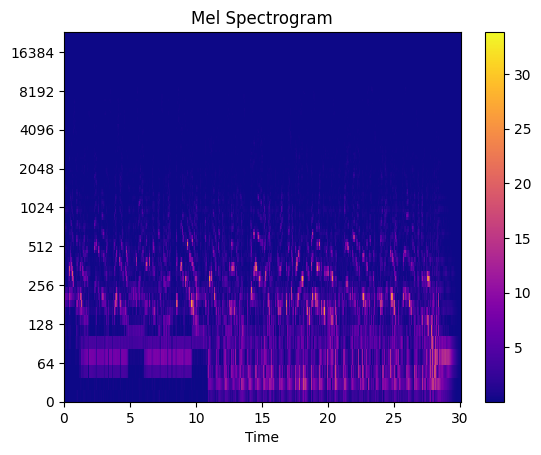

In [4]:
get_mel_spect(wav_path(vid_list[0]))

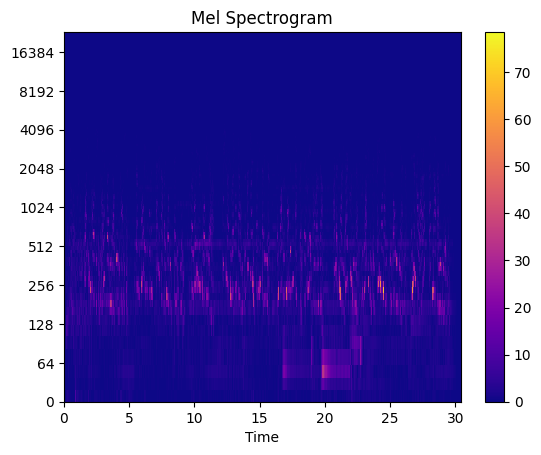

In [26]:
get_mel_spect(wav_path(vid_list[3]))

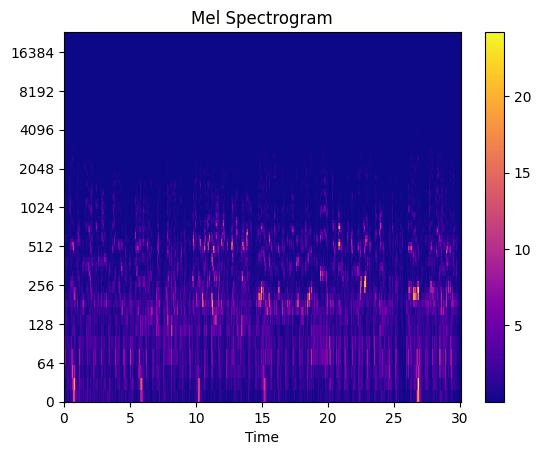

In [7]:
get_mel_spect(wav_path(vid_list[1]))

In [5]:
def get_temp (wav_path):
  audio_arr, sr  = af.read(wav_path)
  spec_arr, _ = af.mel_spectrogram(audio_arr, samplate = sr)
  temp_obj = af.Temporal(frame_length=2048, slide_length=512)
  feature_dic = temp_obj.temporal(data_arr=audio_arr, has_rms=True, has_energy=True, has_zcr=True)
  energy_arr = feature_dic['energy_arr']
  rms_arr = feature_dic['rms_arr']
  zcr_arr = feature_dic['zcr_arr']
  times = np.arange(rms_arr.shape[-1]) * (temp_obj.slide_length / sr)
  fig, axes = plt.subplots(nrows=4, sharex=True)
  af.display.fill_wave(audio_arr, axes=axes[0])
  af.display.fill_plot(times, energy_arr, axes=axes[1], label='Energy')
  af.display.fill_plot(times, rms_arr, axes=axes[2], label='RMS')
  af.display.fill_plot(times, zcr_arr, axes=axes[3], label='ZCR')

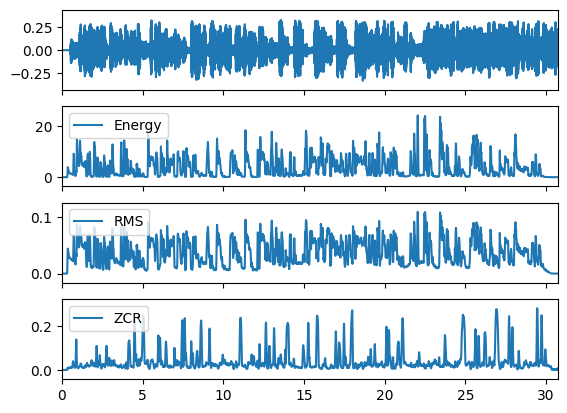

In [27]:
get_temp(wav_path(vid_list[0]))

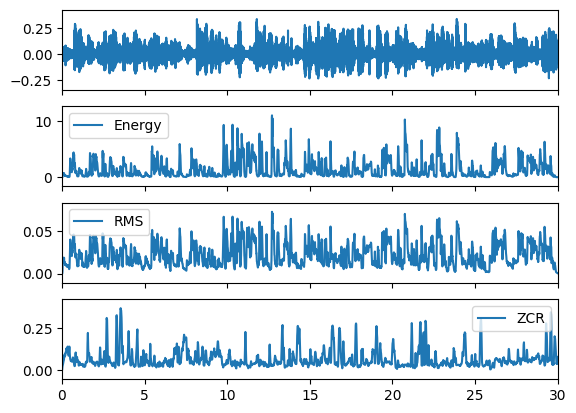

In [8]:
get_temp(wav_path(vid_list[1]))

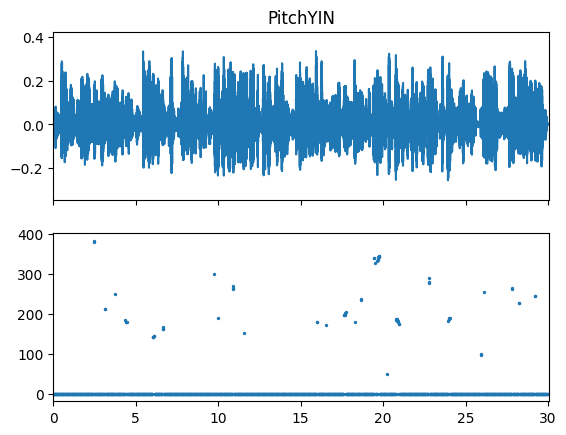

In [9]:
def get_pitch (wav_path):
  audio_arr, sr  = af.read(wav_path)
  spec_arr, _ = af.mel_spectrogram(audio_arr, samplate = sr)
  pitch_obj = af.PitchYIN(samplate=sr)
  fre_arr, v1_arr, v2_arr = pitch_obj.pitch(audio_arr)
  times = np.arange(fre_arr.shape[-1]) * (pitch_obj.slide_length / sr)
  fig, ax = plt.subplots(nrows=2, sharex=True)
  ax[0].set_title('PitchYIN')
  af.display.fill_wave(audio_arr, samplate=sr, axes=ax[0])
  ax[1].scatter(times, fre_arr, s=2)


get_pitch(wav_path(vid_list[1]))

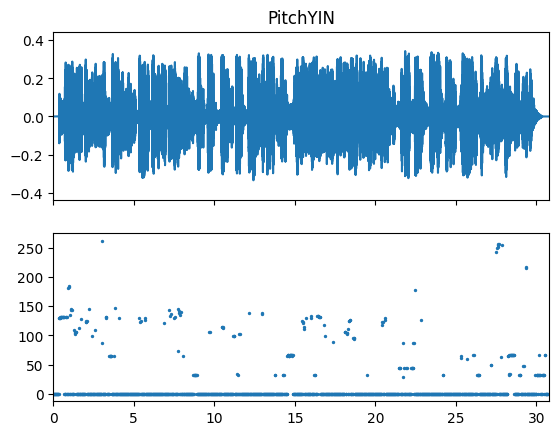

In [28]:
get_pitch(wav_path(vid_list[0]))

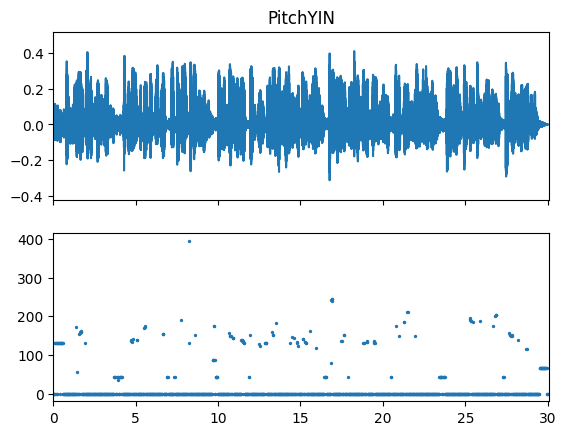

In [20]:
get_pitch(wav_path(vid_list[10]))

In [17]:
def get_flat (wav_path, feat):
  audio_arr, sr  = af.read(wav_path)
  bft_obj = af.BFT(num=2049, samplate=sr, radix2_exp=12, slide_length=1024,
             data_type=SpectralDataType.MAG,
              scale_type=SpectralFilterBankScaleType.LINEAR)
  spec_arr = bft_obj.bft(audio_arr)
  spec_arr = np.abs(spec_arr)
  spectral_obj = af.Spectral(num=bft_obj.num,
                           fre_band_arr=bft_obj.get_fre_band_arr())
  n_time = spec_arr.shape[-1]  
  spectral_obj.set_time_length(n_time)
  flatness_arr = spectral_obj.flatness(spec_arr)
  flux_arr = spectral_obj.flux(spec_arr)
  if feat == "flat":
    fig, ax = plt.subplots(nrows=2, sharex=True)
    fill_wave(audio_arr, samplate=sr, axes=ax[0])
    times = np.arange(0, len(flatness_arr)) * (bft_obj.slide_length / bft_obj.samplate)
    fill_plot(times, flatness_arr, axes=ax[1], label='flatness')
  else: 
    fig, ax = plt.subplots(nrows=2, sharex=True)
    fill_wave(audio_arr, samplate=sr, axes=ax[0])
    times = np.arange(0, len(flux_arr)) * (bft_obj.slide_length / bft_obj.samplate)
    fill_plot(times, flux_arr, axes=ax[1], label='flatness')



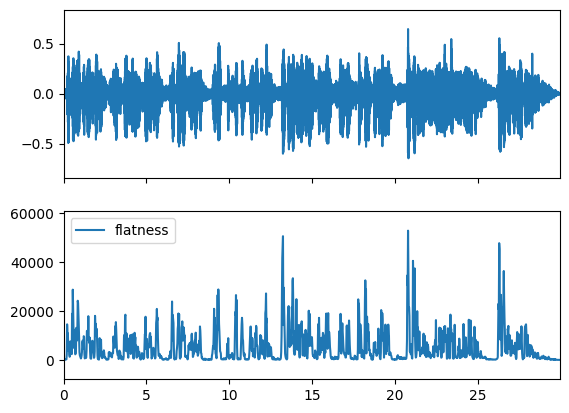

In [19]:
get_flat(wav_path(vid_list[30]), "flux")